# <b>lec04. 딥러닝 CNN - mnist이미지 분류
* https://keras.io/api/datasets/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split                     

#----------------------------------------------------------------------------------- ML모델 
from sklearn.tree import DecisionTreeClassifier
#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
#----------------------------------------------------------------------------------- 평가
from sklearn.metrics  import accuracy_score,      f1_score


import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <b> DATA load
 * https://keras.io/api/datasets/mnist/

* MNIST digits classification dataset
* train : 60,000 28x28 grayscale images of the 10 digits
* test : 10,000 28x28 grayscale images of the 10 digits

In [2]:
from tensorflow.keras.datasets.mnist import load_data

In [3]:
(x_train, y_train), (x_test, y_test) = load_data(path="mnist.npz")
# assert x_train.shape == (60000, 28, 28)
# assert x_test.shape == (10000, 28, 28)
# assert y_train.shape == (60000,)
# assert y_test.shape == (10000,)

In [4]:
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


# 타겟피쳐

[5 0 4 1 9 2 1 3 1 4]


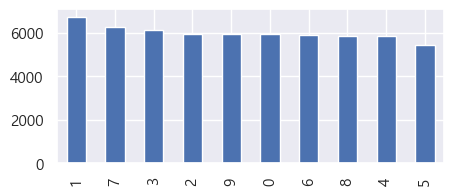

In [5]:
print(y_train[:10])
plt.figure(figsize=(5,2))
pd.Series(y_train).value_counts().plot(kind = "bar")
plt.show()

[7 2 1 0 4 1 4 9 5 9]


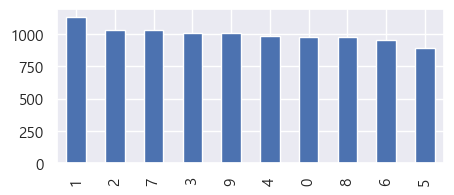

In [6]:
print(y_test[:10])
plt.figure(figsize=(5,2))
pd.Series(y_test).value_counts().plot(kind = "bar")
plt.show()

# data set

In [7]:
#x_train[0]

# <b> EDA

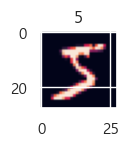

In [8]:
plt.figure(figsize=(1,1))
plt.imshow(x_train[0])
plt.title(y_train[0])
plt.show()

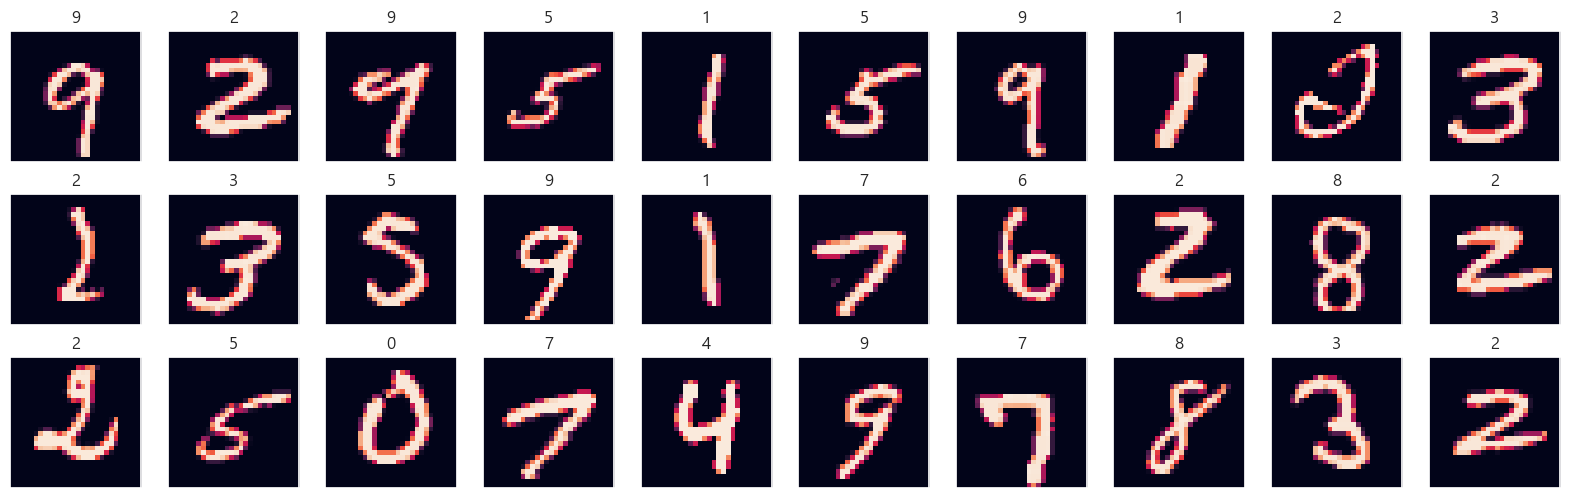

In [9]:
fig, axes = plt.subplots(3,10, figsize=(20,6))
for i, px_arr in enumerate(x_train[170:200]) : 
    row = i // 10
    col = i % 10
    axes[row][col].imshow(px_arr)
    axes[row][col].set_title(y_train[170:200][i])
    # Hide axes,grid
    axes[row][col].grid(False)
    axes[row][col].set_xticks([])
    axes[row][col].set_yticks([])
plt.show()

# <b> 전처리 & 가공
* 픽셀 (RGB : 0 ~ 255) 스케일링 : MinMaxScaler
* 컬러, 노이즈, 채도 조절 : OpenCV
* 이미지 증강(Augmentation)

## 스케일링 : MinMaxScaler
* /255 : 픽셀(0 ~ 255) -> (0 ~ 1)
* 신경망이 학습하기 쉬워짐

In [10]:
x_train = x_train /255
x_test = x_test /255

## 흑백처리 - 지금 안하긴함

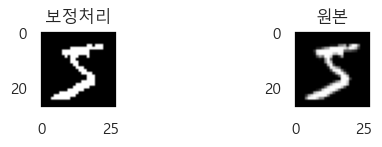

In [11]:
th = 0.5
x_trian_bin = np.where(x_train>th, 1.0, 0.0)
x_test_bin  = np.where(x_test >th, 1.0, 0.0)
plt.figure(figsize=(6,1))

plt.subplot(1,2,1)
plt.imshow(x_trian_bin[0].reshape(28,28), cmap='gray')
plt.grid(False)
plt.title("보정처리")

plt.subplot(1,2,2)
plt.imshow(x_train[0].reshape(28,28), cmap='gray')
plt.grid(False)
plt.title("원본")

plt.show()

# <b> 모델 -ML DL

## <b> ML

In [12]:
x_train[0].shape, x_train[0].reshape(1, 784).shape

((28, 28), (1, 784))

In [13]:
x_train.reshape(60000, -1).shape #-1은 자동으로 계산

(60000, 784)

In [14]:
model = DecisionTreeClassifier(random_state =4545)
model.fit(x_train.reshape(60000, -1), y_train)
pred = model.predict(x_test.reshape(10000, -1))
accuracy = accuracy_score(y_test, pred)
print(f"accuracy : {accuracy:.4f}")

accuracy : 0.8756


## <b> DL

In [15]:
model = Sequential([
    Dense(10 , activation = "relu" , input_dim=784), # ------------ input layer
    Dense(16 , activation = "relu"),               # ------------ hidden layer 3
    Dense(24 , activation = "relu"),
    Dense(8  , activation = "relu"),
    Dense(10  , activation = "softmax")                # ------------ output layer 
])
model.compile(loss ="sparse_categorical_crossentropy", optimizer = "adam", metrics=["accuracy"]) 

In [16]:
model.summary() 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │           7,850 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 24)                  │             408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │              90 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,724 (34.08 KB)

 Trainable params: 8,724 (34.08 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
X80 = x_train.reshape(60000, -1)
y80 = y_train
X20 = x_test.reshape(10000, -1)
y20 = y_test
res = model.fit(X80, y80,  epochs=20, validation_data = (X20, y20))
loss, acc = model.evaluate(X20, y20)
print(f"acc : {acc:.4f} , loss:{loss:.4f}")

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8274 - loss: 0.5763 - val_accuracy: 0.9162 - val_loss: 0.2954
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9172 - loss: 0.2841 - val_accuracy: 0.9176 - val_loss: 0.2858
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9273 - loss: 0.2490 - val_accuracy: 0.9326 - val_loss: 0.2341
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9332 - loss: 0.2294 - val_accuracy: 0.9346 - val_loss: 0.2281
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9365 - loss: 0.2142 - val_accuracy: 0.9337 - val_loss: 0.2316
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9398 - loss: 0.2037 - val_accuracy: 0.9372 - val_loss: 0.2166
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9433 - loss: 0.1923 - val_accuracy: 0.9362 - val_loss: 0.2288
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9448 - loss: 0.1872 - 

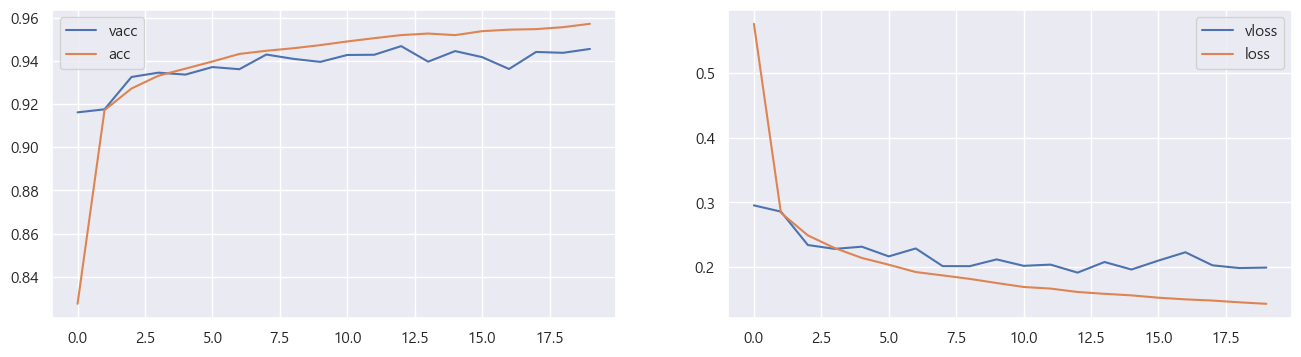

In [18]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
vacc = res.history["val_accuracy"]
acc  = res.history["accuracy"]
plt.plot(range(20), vacc , label="vacc")
plt.plot(range(20), acc  , label="acc")
plt.legend()

plt.subplot(1,2,2)
vloss = res.history["val_loss"]
loss = res.history["loss"]
plt.plot(range(20),vloss , label="vloss")
plt.plot(range(20),loss  , label="loss")
plt.legend()
plt.show()

강사님이랑 그래프 다른 이유 = 가중치가 다름<br>
모델 여러번 돌리면 학습 여러번이라 del model하고 다시 모델해서 학습하면댐

### 오답 체크

In [19]:
proba = model.predict(X20) # 각 숫자 확률
pred = np. argmax(proba, axis = 1) # 확률 가장 큰 숫자 선택
pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step


array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [20]:
pred.shape, y_test.shape

((10000,), (10000,))

In [21]:
from sklearn.metrics import confusion_matrix # confusion_matrix(실제값, 예측값)을 비교해서 어떤걸 맞추고 틀렷는지 표로 보여줌

cm = confusion_matrix(y_test, pred)
print(cm)


[[ 968    0    1    1    3    1    1    3    2    0]
 [   0 1108    5    4    1    0    1    3   13    0]
 [   6    2  976   10    6    2    7   17    4    2]
 [   1    0   23  928    2   21    2   12   17    4]
 [   1    2    4    0  943    0    7    5    4   16]
 [   9    6    5   20    3  804   15    4   20    6]
 [  15    2    6    1   15    5  908    0    6    0]
 [   2    5   19    2    4    2    0  975    0   19]
 [  11    0    8   13   15    9    6    4  898   10]
 [  11    4    0    4   29    1    0    8    4  948]]


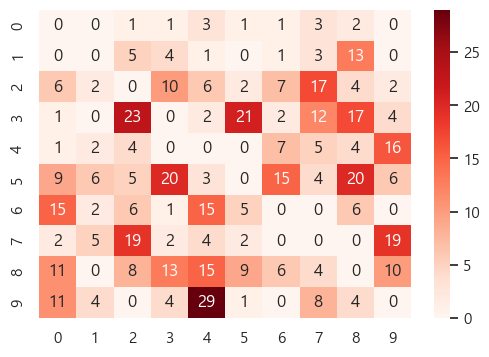

In [22]:
cmdf = pd.DataFrame(cm)
for i in range(10):
    cmdf.iloc[i,i] = 0   #---- 대각방향 정답 (정답빼고 오답만 보자)

plt.figure(figsize=(6,4))
sns.heatmap(cmdf, cmap="Reds", fmt='d', annot=True)
plt.show()

In [23]:
oxdf = pd.DataFrame( {"y":y_test, "pred" : pred}) #oxdf.shape : 전체 실제값.예측값 표 크기
# idx = oxdf [oxdf['y'] != oxdf['pred']].index
# xdf = oxdf.loc[idx, : ] # xdf.shape : 틀린것만 모은 표 크기
# print (xdf.shape)
oxdf.shape

(10000, 2)

In [24]:
oxdf = pd.DataFrame({"y": y_test, "pred": pred}) # oxdf : 전체 실제값, 예측값 오답이 섞인거
oxdf["img"] = list( x_test.reshape(10000,-1)) #(x_test)해서[(28*28)]도가능
print(oxdf.shape)
oxdf.head(1)


(10000, 3)


,y,pred,img
0,7,7,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]"


In [25]:
xdf = oxdf[oxdf['y'] != oxdf['pred']] # xdf : 틀린것만 모은 데이터
print(xdf.shape)
xdf.head(1)

(544, 3)


,y,pred,img
8,5,6,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]"


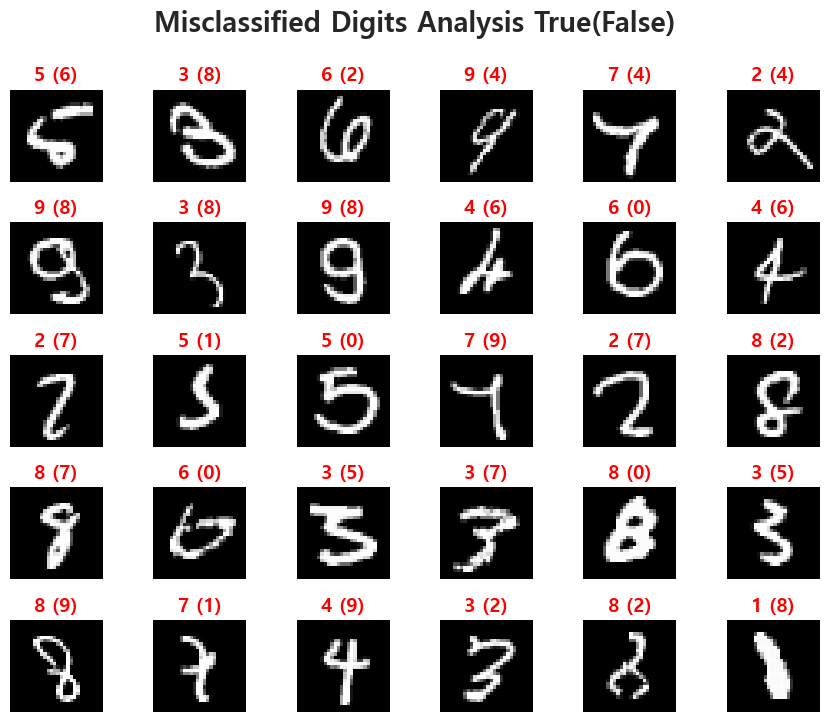

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

oxdf = pd.DataFrame( { "y":y_test, "pred":pred } )
wrong_index = oxdf[  oxdf['y'] != oxdf['pred']  ].index
wrong_index.shape      # y_test - 10,000개 중 616개 틀림


# Numpy 배열 인덱싱으로 오답 이미지와 예측 정보만 끄집어냅니다.
# 배열 이름[인덱스 리스트] 문법을 사용하여 깔끔하게 처리합니다.
x_test_wrong = x_test[wrong_index]
y_test_wrong = y_test[wrong_index]
pred_wrong = pred[wrong_index]

# --- 2. 최적화된 시각화 설정 ---
rows, cols = 5, 6 # 5x6 그리드로 더 많은 이미지 확인
plt.figure(figsize=(9,7.5)) # 전체 피겨 크기

# 서브플롯 간의 여백을 수동으로 세밀하게 조정합니다.
# wspace: 가로 간격, hspace: 세로 간격 (0에 가까울수록 딱 붙음)
plt.subplots_adjust(left=0.01, right=0.99, top=0.92, bottom=0.01, wspace=0.1, hspace=0.25)

plt.suptitle("Misclassified Digits Analysis True(False)", fontsize=20, fontweight='bold', y=0.96)

# 오답 데이터셋(x_test_ox 등)에서 Top 25개만 순회
for i in range(rows * cols):
    if i >= len(x_test_wrong): break # 오답이 25개 미만일 경우 방지
    
    plt.subplot(rows, cols, i + 1)
    
    # 이미지 데이터는 원본 배열(x_test_ox)에서 바로 가져옵니다.
    # 784차원으로 펼쳐져 있다면 다시 (28, 28)로 리셰이프해야 사진으로 보입니다.
    img_data = x_test_wrong[i].reshape(28, 28)
    plt.imshow(img_data, cmap='gray')
    
    # 원본 데이터 인덱스와 오답 정보를 제목에 깔끔하게 표시
    origin_idx = wrong_index[i]
    plt.title(f"{y_test_wrong[i]} ({pred_wrong[i]})", 
              fontsize=14, color='red', fontweight='bold'
              if y_test_wrong[i] != pred_wrong[i] else 'black')
    plt.axis('off') # 축 눈금 제거

# plt.tight_layout()#은 사용하지 않거나, 
plt.tight_layout(rect=[0, 0, 1, 0.97]) #처럼 rect 옵션을 줘서 suptitle과 겹침을 방지합니다.
plt.show() ;

In [27]:
print(xdf.shape)

(544, 3)


# <font color=red><b> 모델 -CNN

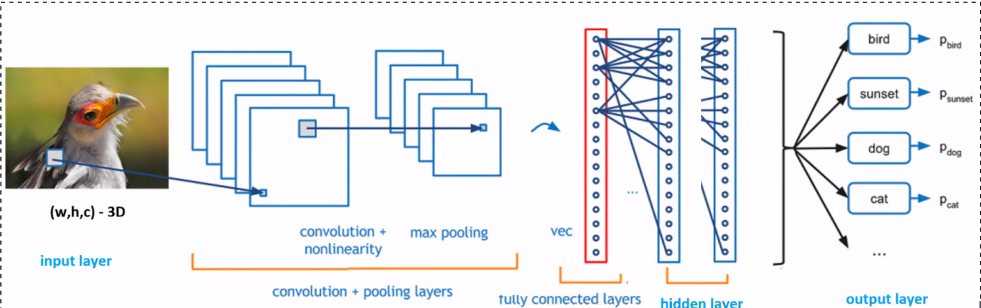

## CNN모델

* https://keras.io/api/layers/convolution_layers/convolution2d/
* https://keras.io/api/layers/pooling_layers/max_pooling2d/
* https://keras.io/api/layers/reshaping_layers/flatten/
* https://keras.io/api/layers/core_layers/dense/

```python
keras.layers.Conv2D(
    filters,
    kernel_size,
    strides=(1, 1),
    padding="valid",
    data_format=None,
    dilation_rate=(1, 1),
    groups=1,
    activation=None,
    use_bias=True,
    kernel_initializer="glorot_uniform",
    bias_initializer="zeros",
    kernel_regularizer=None,
    bias_regularizer=None,
    activity_regularizer=None,
    kernel_constraint=None,
    bias_constraint=None,
    **kwargs
)


keras.layers.MaxPooling2D(
    pool_size=(2, 2), strides=None, padding="valid", data_format=None, name=None, **kwargs
)

keras.layers.Flatten(data_format=None, **kwargs)


keras.layers.Dense(
    units,
    activation=None,
    use_bias=True,
    kernel_initializer="glorot_uniform",
    bias_initializer="zeros",
    kernel_regularizer=None,
    bias_regularizer=None,
    activity_regularizer=None,
    kernel_constraint=None,
    bias_constraint=None,
    lora_rank=None,
    lora_alpha=None,
    quantization_config=None,
    **kwargs
)


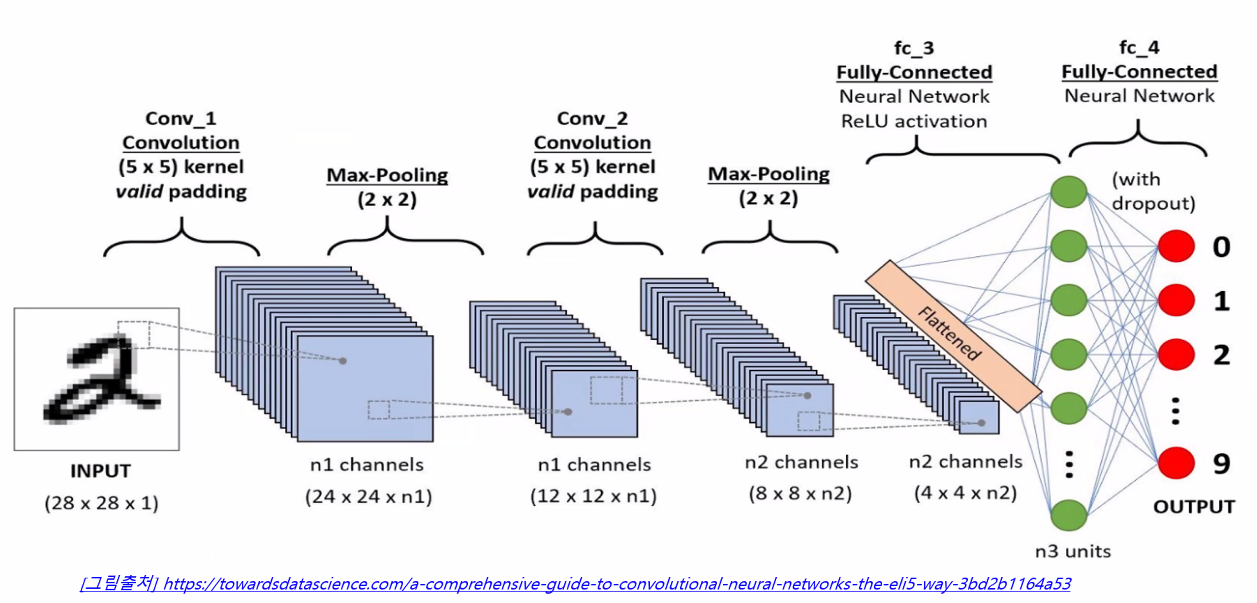

In [28]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [29]:
model = Sequential([


    Conv2D (filters = 16, kernel_size = (5,5), activation="relu", input_shape=(28,28,1)), #   strides=(1, 1), padding="valid"
    MaxPooling2D(pool_size=(2, 2)), #strides=None, padding="valid"
    Conv2D (filters = 24, kernel_size = (5,5), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten( ),
    Dense(16 , activation = "relu"),               # ------------ hidden layer 3
    Dense(10  , activation = "softmax")                # ------------ output layer 
])
model.compile(loss ="sparse_categorical_crossentropy", optimizer = "adam", metrics=["accuracy"]) 

In [30]:
model.summary() #모델 만들어진거 뼈대

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 24, 24, 16)          │             416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 12, 12, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 8, 8, 24)            │           9,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 4, 4, 24)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 384)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 16)                  │           6,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 10)                  │             170 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,370 (63.95 KB)

 Trainable params: 16,370 (63.95 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
x_train.shape

(60000, 28, 28)

In [32]:
X80 = x_train.reshape(60000, 28, 28, 1)
y80 = y_train
X20 = x_test.reshape(10000,  28, 28, 1)
y20 = y_test
X80.shape

res = model.fit(X80, y80,  epochs=20, validation_data = (X20, y20))
loss, acc = model.evaluate(X20, y20)
print(f"acc : {acc:.4f} , loss:{loss:.4f}")

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9361 - loss: 0.2064 - val_accuracy: 0.9786 - val_loss: 0.0678
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9805 - loss: 0.0650 - val_accuracy: 0.9827 - val_loss: 0.0545
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9847 - loss: 0.0490 - val_accuracy: 0.9862 - val_loss: 0.0430
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9871 - loss: 0.0400 - val_accuracy: 0.9881 - val_loss: 0.0361
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9895 - loss: 0.0330 - val_accuracy: 0.9890 - val_loss: 0.0357
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9912 - loss: 0.0268 - val_accuracy: 0.9905 - val_loss: 0.0322
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9923 - loss: 0.0242 - val_accuracy: 0.9885 - val_loss: 0.0404
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9935 - loss: 0.0198 - 

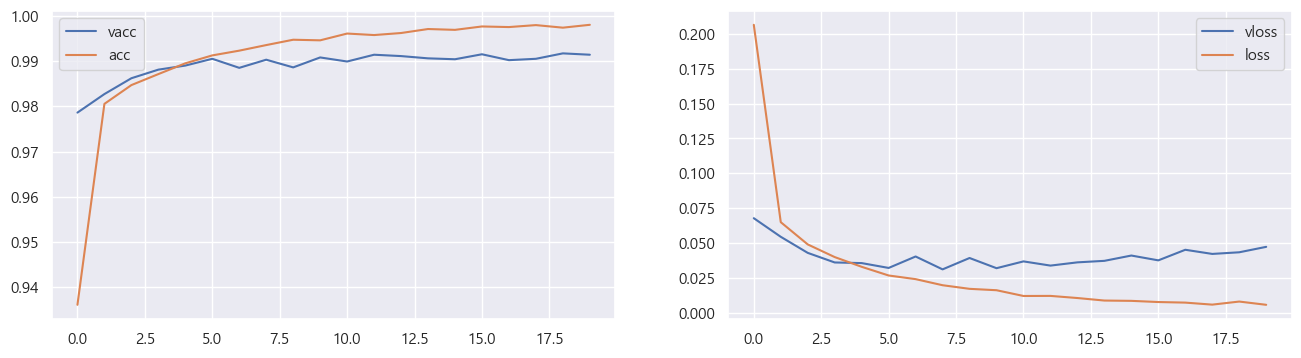

In [33]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
vacc = res.history["val_accuracy"]
acc  = res.history["accuracy"]
plt.plot(range(20), vacc , label="vacc")
plt.plot(range(20), acc  , label="acc")
plt.legend()

plt.subplot(1,2,2)
vloss = res.history["val_loss"]
loss = res.history["loss"]
plt.plot(range(20),vloss , label="vloss")
plt.plot(range(20),loss  , label="loss")
plt.legend()
plt.show()

## 모델 성능 비교

* ML : acc : 0.8756
* DL : acc : 0.9450 , loss:0.1969
* CNN : acc : 0.9911 , loss:0.0461